<a href="https://colab.research.google.com/github/ahmed-zunaira/UTAT-Onboarding-Project/blob/main/UTAT_DL_Onboarding_Tuning_Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
# importing libraries
import numpy as np
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.metrics import r2_score
from skorch import NeuralNetRegressor
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [ ]:
# loading the data
file_path = "/content/simpler_data_rwc.csv"
with open(file_path, 'r') as csvfile:
  data_reader = csv.reader(csvfile)

  data = []
  for row in data_reader:
    data.append(row)

data_np = np.array(data)
data_tensor = torch.from_numpy (data_np[1:,7:].astype(np.float32))
labels_tensor = torch.from_numpy (data_np[1:, 1:4].astype(np.float32))

In [ ]:
# defining MLP with hyperparameters (layer size, activation function, and normalization scheme)

class MLP (nn.Module):
  def __init__ (self, neurons1=128, neurons2=128, activation='relu', normalization='none'):
    super (MLP, self).__init__()
    self.activation_type = activation

    self.layer1 = nn.Linear(210, neurons1)
    self.layer2 = nn.Linear (neurons1, neurons2)
    self.layer3 = nn.Linear (neurons2, 3)

    self.normalize1 = self.get_norm(normalization, neurons1)
    self.normalize2 = self.get_norm(normalization, neurons2)

  def forward(self, specs):
    activation1 = self.layer1(specs)
    activation1 = self.normalize1(activation1)
    activation1 = self.get_activation(activation1)
    activation2 = self.layer2(activation1)
    activation2 = self.normalize2(activation2)
    activation2 = self.get_activation(activation2)
    activation3 = self.layer3(activation2)
    output = torch.softmax(activation3, dim=-1)
    return output

  def get_norm (self, normalization, neurons):
    if (normalization == 'layer_norm'):
      return nn.LayerNorm(neurons)
    else:
      return nn.Identity()

  def get_activation (self, layer):
    if (self.activation_type == 'relu'):
      return F.relu(layer)
    elif (self.activation_type == 'leaky_relu'):
      return F.leaky_relu(layer)
    elif (self.activation_type == 'tanh'):
      return F.tanh(layer)
    elif (self.activation_type == 'silu'):
      return F.silu(layer)

In [ ]:
# define model
model = NeuralNetRegressor(module=MLP, criterion=nn.MSELoss, optimizer=optim.AdamW, verbose=0)

# define search space
param_dist = {
    'module__neurons1': [32, 64, 128, 256],
    'module__neurons2': [16, 32, 64, 128],
    'module__activation': ['relu', 'leaky_relu', 'tanh', 'silu'],
    'module__normalization': ['layer_norm', 'none'],
    'batch_size' : [16, 32, 64]
}

# define search
search = GridSearchCV (estimator=model, param_grid=param_dist, scoring='r2', cv=3)

data_np = data_tensor.numpy()
labels_np = labels_tensor.float().numpy()

# execute search
result = search.fit(data_np, labels_np)

# summarize result
print ("Best score:", result.best_score_)
print ("Best Hyperparameters: ", result.best_params_)

Best score: 0.41748230655988056
Best Hyperparameters:  {'batch_size': 64, 'module__activation': 'silu', 'module__neurons1': 32, 'module__neurons2': 64, 'module__normalization': 'none'}


In [ ]:
# function definitions

def plot_loss(epochs):
  val_loss = np.loadtxt("model_MLP_epoch{}_val_loss.csv".format(epochs))
  train_loss = np.loadtxt("model_MLP_epoch{}_train_loss.csv".format(epochs))

  plt.title("Train & Validation Loss")

  plt.plot (range(1, epochs+1), train_loss, label="Train")
  plt.plot (range(1, epochs+1), val_loss, label="Validation")

  plt.xlabel ("Epoch")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

def plot_r2 (data_type, epochs):
  r2_values = np.loadtxt("model_MLP_epoch{}_{}_r2.csv".format(epochs, data_type))

  plt.title ("Predicted vs. True Abundances: Validation (R-Squared)")

  plt.plot (range(1, epochs+1), r2_values)

  plt.xlabel ("Epoch")
  plt.ylabel("R-Squared Value")
  plt.show()

def plot_test ():
  true_values = np.loadtxt("model_MLP_test_output_true.csv")
  predicted_values = np.loadtxt("model_MLP_test_output_prediction.csv")

  plt.title ("Predicted vs. True Abundances: Testing")

  plt.scatter(true_values[:,0], predicted_values[:,0], color='green', label='GV')
  plt.scatter(true_values[:,1], predicted_values[:,1], color='red', label='NPV')
  plt.scatter(true_values[:,2], predicted_values[:,2], color='brown', label='Soil')

  min_val = np.min(true_values)
  max_val = np.max(true_values)
  plt.plot ([min_val, max_val], [min_val, max_val], linestyle='--')

  plt.legend(loc='best')

  plt.xlabel("True Abundance")
  plt.ylabel("Predicted Abundance")

  plt.show()

def test_MLP (net, batch_size, data, labels):
  data_test = data[1464:]
  labels_test = labels[1464:]
  total_loss_test = 0.0
  model_outputs = []

  test_dataset = TensorDataset(data_test, labels_test)
  test_dataloader = DataLoader (test_dataset, batch_size=batch_size, shuffle=False)

  net.eval()

  criterion = nn.MSELoss()
  with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_dataloader):
      outputs = net(inputs)
      labels = labels.float().view(-1,3)
      model_outputs.append(outputs.detach().numpy())
      loss_test = criterion (outputs, labels)

      total_loss_test += loss_test.item()

  full_outputs = np.concatenate(model_outputs, axis=0)
  full_labels = labels_test.detach().view(-1,3).numpy()

  r2 = r2_score (full_labels, full_outputs)
  loss = total_loss_test / (i+1)

  np.savetxt ("model_MLP_test_output_true.csv", full_labels)
  np.savetxt ("model_MLP_test_output_prediction.csv", full_outputs)

  return r2, loss


# evaluating the model on validation data
def evaluate_MLP (net, batch_size, data, labels_val, criterion):
  total_loss_val = 0.0
  model_outputs = []

  val_dataset = TensorDataset(data, labels_val)
  val_dataloader = DataLoader (val_dataset, batch_size=batch_size, shuffle=False)

  net.eval()
  with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_dataloader):
      outputs = net(inputs)
      labels = labels.float().view(-1,3)
      model_outputs.append(outputs.detach().numpy())
      loss_val = criterion (outputs, labels)

      total_loss_val += loss_val.item()

  full_outputs = np.concatenate(model_outputs, axis=0)
  full_labels = labels_val.detach().view(-1,3).numpy()

  r2 = r2_score (full_labels, full_outputs)
  loss = total_loss_val / (i+1)

  return r2, loss


# defining training function for model
def train_MLP (net, batch_size, data_tensor, labels_tensor, num_epochs=30):
  # setting manual seed for replication
  torch.manual_seed(1)
  best_epoch = 0
  best_val_r2 = 0

  net.train()

  # splitting data
  data_train = data_tensor[0:1206] # 70%
  labels_train = labels_tensor[0:1206]

  data_val = data_tensor [1206:1464] # 15%
  labels_val = labels_tensor [1206:1464]

  train_dataset = TensorDataset(data_tensor, labels_tensor)
  train_dataloader = DataLoader (train_dataset, batch_size=batch_size, shuffle=True)

  # setting loss function and optimizer
  criterion = nn.MSELoss()
  optimizer = optim.AdamW(net.parameters())

  # setting up arrays to store losses over epochs
  train_loss = np.zeros(num_epochs)
  val_loss = np.zeros(num_epochs)
  val_r2 = np.zeros(num_epochs)

  start_time = time.time()

  for epoch in range(num_epochs):
    total_loss_train = 0.0

    for i, (inputs, labels) in enumerate(train_dataloader):

      optimizer.zero_grad()

      outputs = net(inputs)

      loss = criterion(outputs, labels.float())
      loss.backward()

      optimizer.step()

      total_loss_train += loss.item()

    train_loss[epoch] = float(total_loss_train) / (i+1)
    val_r2[epoch], val_loss[epoch] = evaluate_MLP (net, batch_size, data_val, labels_val, criterion)

    if (val_r2[epoch] > best_val_r2):
      best_val_r2= val_r2[epoch]
      best_epoch = epoch+1

    print (("Epoch {}: Train loss: {}, Validation loss: {}, Validation r2: {}").format(epoch+1, train_loss[epoch], val_loss[epoch], val_r2[epoch]))
    torch.save(net.state_dict(), "model_MLP_epoch{}".format(epoch+1))

  print ("Training is complete.")
  end_time = time.time()
  total_time = end_time - start_time

  print ("Total time: {:.2f} seconds". format(total_time))

  # putting training & validation loss + loss r^2 values in files to plot after
  np.savetxt ("model_MLP_epoch{}_train_loss.csv".format(num_epochs), train_loss)
  np.savetxt ("model_MLP_epoch{}_val_loss.csv".format(num_epochs), val_loss)
  np.savetxt ("model_MLP_epoch{}_val_r2.csv".format(num_epochs), val_r2)

  return best_epoch

In [ ]:
mlp = MLP(result.best_params_['module__neurons1'], result.best_params_['module__neurons2'], result.best_params_['module__activation'], result.best_params_['module__normalization'])

epoch_val = train_MLP(mlp, result.best_params_['batch_size'], data_tensor, labels_tensor, 100)

Epoch 1: Train loss: 0.09238846682839924, Validation loss: 0.08427109122276306, Validation r2: 0.11545290797948837
Epoch 2: Train loss: 0.06568146179671641, Validation loss: 0.060752404108643535, Validation r2: 0.43301233649253845
Epoch 3: Train loss: 0.050543692928773386, Validation loss: 0.04968601427972317, Validation r2: 0.5260500311851501
Epoch 4: Train loss: 0.04742659600796523, Validation loss: 0.04407605528831482, Validation r2: 0.5691015124320984
Epoch 5: Train loss: 0.044921224315961204, Validation loss: 0.04395339004695416, Validation r2: 0.5701729655265808
Epoch 6: Train loss: 0.041542915282426054, Validation loss: 0.03675714358687401, Validation r2: 0.6332947611808777
Epoch 7: Train loss: 0.03902537886191298, Validation loss: 0.03441837802529335, Validation r2: 0.6721275448799133
Epoch 8: Train loss: 0.03694181778916606, Validation loss: 0.03298227339982986, Validation r2: 0.6645228266716003
Epoch 9: Train loss: 0.036807627589614304, Validation loss: 0.03295857775956392, V

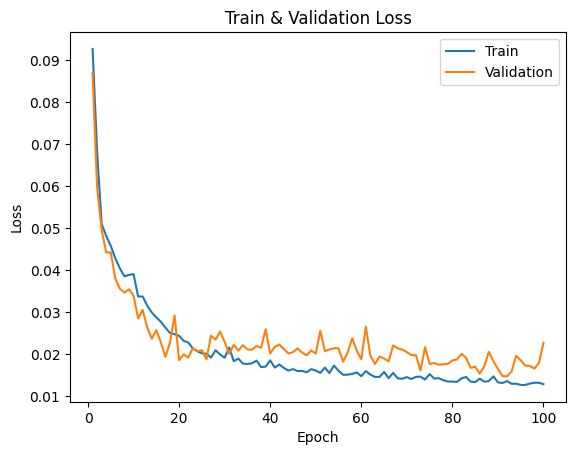

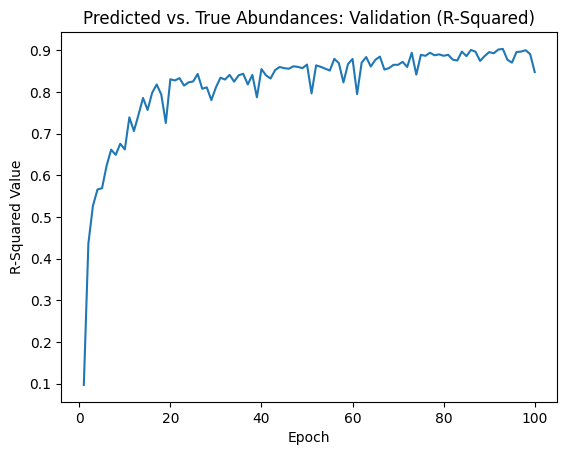

In [ ]:
plot_loss(100)
plot_r2('val', 100)

Epoch 1: Train loss: 0.07612624847226673, Validation loss: 0.06059016287326813, Validation r2: 0.43487927317619324
Epoch 2: Train loss: 0.04898964461904985, Validation loss: 0.04541460163891316, Validation r2: 0.5654159784317017
Epoch 3: Train loss: 0.045187680809586135, Validation loss: 0.04438821859657764, Validation r2: 0.5624144673347473
Epoch 4: Train loss: 0.04223112092801818, Validation loss: 0.037650832533836366, Validation r2: 0.6405739784240723
Epoch 5: Train loss: 0.03906226378900034, Validation loss: 0.03264702372252941, Validation r2: 0.6733148097991943
Epoch 6: Train loss: 0.0362917798122874, Validation loss: 0.031721266359090804, Validation r2: 0.7056310772895813
Epoch 7: Train loss: 0.03342033888178843, Validation loss: 0.028138557448983192, Validation r2: 0.7372002601623535
Epoch 8: Train loss: 0.031374181931217514, Validation loss: 0.03676171638071537, Validation r2: 0.6116097569465637
Epoch 9: Train loss: 0.03069916947020425, Validation loss: 0.027719202265143395, Va

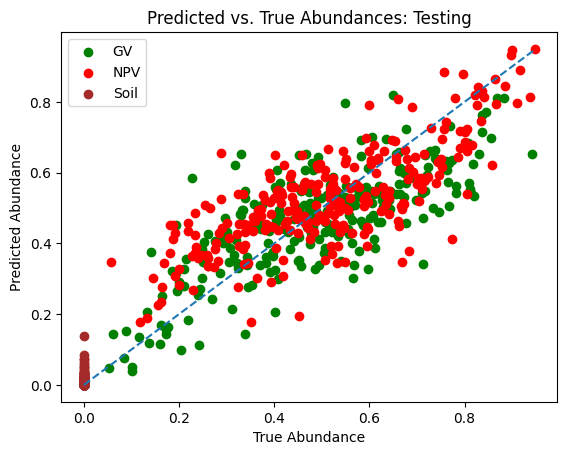

In [ ]:
mlp = MLP()

train_MLP(mlp, result.best_params_['batch_size'], data_tensor, labels_tensor, epoch_val)

test_r2, test_loss = test_MLP(mlp, result.best_params_['batch_size'], data_tensor, labels_tensor)

print ("R-Squared value of testing data:", test_r2)
plot_test()